# hw3: Обучение без учителя

*Спасибо ещё одному великому курсу mlcourse.ai и авторам: Ольга Дайховская (@aiho в Slack ODS), Юрий Кашницкий (@yorko в Slack ODS).*

### О задании

В этом задании мы разберемся с тем, как работают методы снижения размерности и кластеризации данных. Заодно еще раз попрактикуемся в
задаче классификации.

Мы будем работать с набором данных [Samsung Human Activity Recognition](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones). Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S3 (подробнее про признаки – по ссылке на UCI выше), также известен вид активности человека с телефоном в кармане – ходил ли он, стоял, лежал, сидел или шел вверх/вниз по лестнице.

Вначале мы представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков. Затем решим задачу определения вида физической активности именно как задачу классификации.

**Заполните код в клетках (где написано "Ваш код здесь") и ответьте на вопросы, выделив ответ полужирным** (``` **выделить двойными звёздочками** ```).

### Оценивание и штрафы
Вам необходимо ответить на 10 вопросов и выполнить 2 задания. Каждое из заданий и вопросов имеет определенную «стоимость» (указана в скобках). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw3-unsupervised.ipynb``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце "hw3" в строке со своей фамилией о том, что вы выполнили работу и оставить ссылку на ноутбук.


In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm as tqdm_notebook

%matplotlib inline
from matplotlib import pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 17

In [29]:
X_train = np.loadtxt("datasets/samsung_HAR/samsung_train.txt")
y_train = np.loadtxt("datasets/samsung_HAR/samsung_train_labels.txt").astype(int)

X_test = np.loadtxt("datasets/samsung_HAR/samsung_test.txt")
y_test = np.loadtxt("datasets/samsung_HAR/samsung_test_labels.txt").astype(int)

In [30]:
# Проверим размерности
assert(X_train.shape == (7352, 561) and y_train.shape == (7352,))
assert(X_test.shape == (2947, 561) and y_test.shape == (2947,))

Для кластеризации нам не нужен вектор ответов, поэтому будем работать с объединением обучающей и тестовой выборок. Объедините *X_train* с *X_test*, а *y_train* – с *y_test*.

In [31]:
# Ваш код здесь
X = np.vstack([X_train, X_test])
y = np.hstack([y_train, y_test])

Определим число уникальных значений меток целевого класса.

In [32]:
np.unique(y)

array([1, 2, 3, 4, 5, 6])

In [33]:
n_classes = np.unique(y).size

[Эти метки соответствуют:](https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.names)
- 1 - ходьбе
- 2 - подъему вверх по лестнице
- 3 - спуску по лестнице
- 4 - сидению
- 5 - стоянию
- 6 - лежанию

*уж простите, если звучание этих существительных кажется корявым :)*

Отмасштабируйте выборку с помощью `StandardScaler` с параметрами по умолчанию.

In [34]:
# Ваш код здесь
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Понижаем размерность с помощью PCA, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии исходных (отмасштабированных) данных. Используйте отмасштабированную выборку и зафиксируйте random_state (константа RANDOM_STATE).

In [35]:
# Ваш код здесь
pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

**Вопрос 1:** (1 балл)

Какое минимальное число главных компонент нужно выделить, чтобы объяснить 90% дисперсии исходных (отмасштабированных) данных?

**Варианты:**
- 56
- **65** - правильный ответ
- 66
- 193

In [36]:
# Ваш код здесь
print(f"Число компонент: {pca.n_components_}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.4f}")

Число компонент: 65
Объясненная дисперсия: 0.9005


**Вопрос 2:** (0.5 баллов)

Сколько процентов дисперсии приходится на первую главную компоненту? Округлите до целых процентов.

**Варианты:**
- 45
- **51** - правильный ответ
- 56
- 61

In [37]:
# Ваш код здесь
print(f"Первая компонента объясняет: {round(pca.explained_variance_ratio_[0] * 100)}%")

Первая компонента объясняет: 51%


Визуализируйте данные в проекции на первые две главные компоненты.

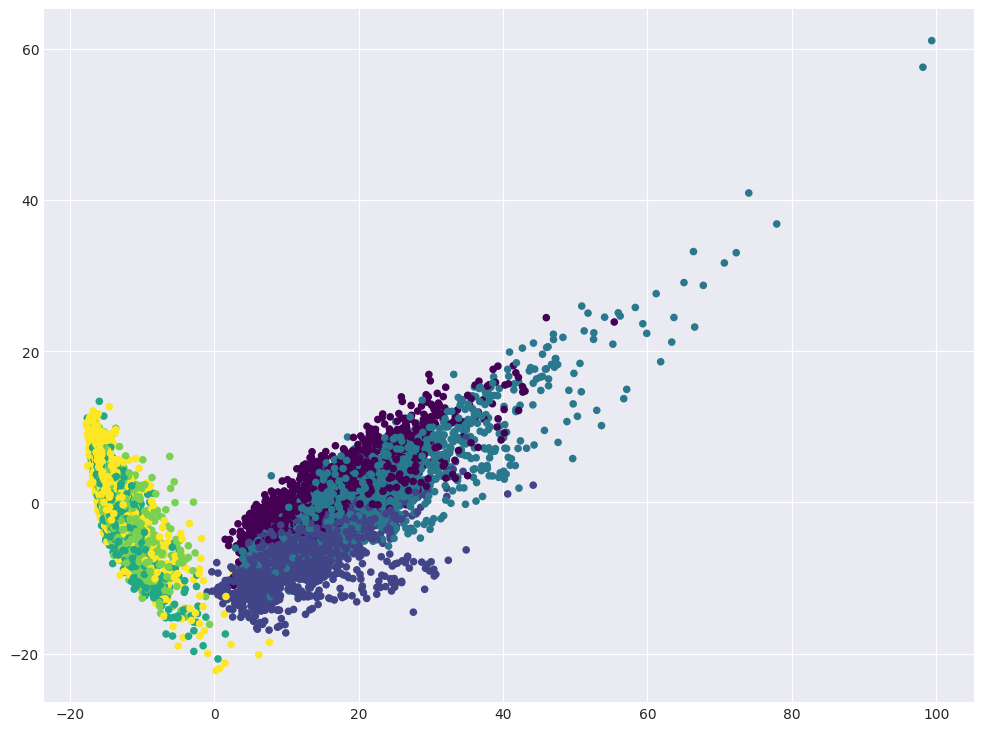

In [38]:
# Ваш код здесь
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, cmap='viridis');

**Вопрос 3:** (0.5 баллов)

Если все получилось правильно, Вы увидите сколько-то кластеров, почти идеально отделенных друг от друга. Какие виды активности входят в эти кластеры?<br>

**Ответ:**
- 1 кластер: все 6 активностей
- **2 кластера: (ходьба, подъем вверх по лестнице, спуск по лестнице) и (сидение, стояние, лежание)** - правильный ответ
- 3 кластера: (ходьба), (подъем вверх по лестнице, спуск по лестнице) и (сидение, стояние, лежание)
- 6 кластеров

In [41]:
# Вычисление меток кластеров с использованием KMeans
kmeans_temp = KMeans(n_clusters=n_classes, n_init=100, random_state=RANDOM_STATE)
cluster_labels_temp = kmeans_temp.fit_predict(X_pca)

# Вычисление максимальной пропорции для каждой активности
crosstab = pd.crosstab(y, cluster_labels_temp)
max_proportions = crosstab.max(axis=1) / crosstab.sum(axis=1)
activities = ['ходьба', 'подъем вверх по лестнице', 'спуск по лестнице', 'сидение', 'стояние', 'лежание']

for i, activity in enumerate(activities):
    print(f"{activity}: {max_proportions.iloc[i]:.4f} ({max_proportions.iloc[i]*100:.2f}%)")

best_activity_idx = max_proportions.idxmax()
print(f"\nЛучше всего отделена активность #{best_activity_idx}: {activities[best_activity_idx-1]}")


ходьба: 0.5244 (52.44%)
подъем вверх по лестнице: 0.8038 (80.38%)
спуск по лестнице: 0.6330 (63.30%)
сидение: 0.6950 (69.50%)
стояние: 0.7051 (70.51%)
лежание: 0.8014 (80.14%)

Лучше всего отделена активность #2: подъем вверх по лестнице


------------------------------

**Задание 1.** (1 балл)

Сделайте кластеризацию данных методом `KMeans` (собственная имплементация и готовая реализация), обучив модель на данных со сниженной за счет PCA размерностью. В данном случае мы подскажем, что нужно искать именно 6 кластеров, но в общем случае мы не будем знать, сколько кластеров надо искать.

Параметры:

- **n_clusters** = n_classes (число уникальных меток целевого класса)
- **n_init** = 100
- **random_state** = RANDOM_STATE (для воспроизводимости результата)

Остальные параметры со значениями по умолчанию.

In [42]:
# Ваш код здесь
kmeans = KMeans(n_clusters=n_classes, n_init=100, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_pca)

Визуализируйте данные в проекции на первые две главные компоненты. Раскрасьте точки в соответствии с полученными метками кластеров.

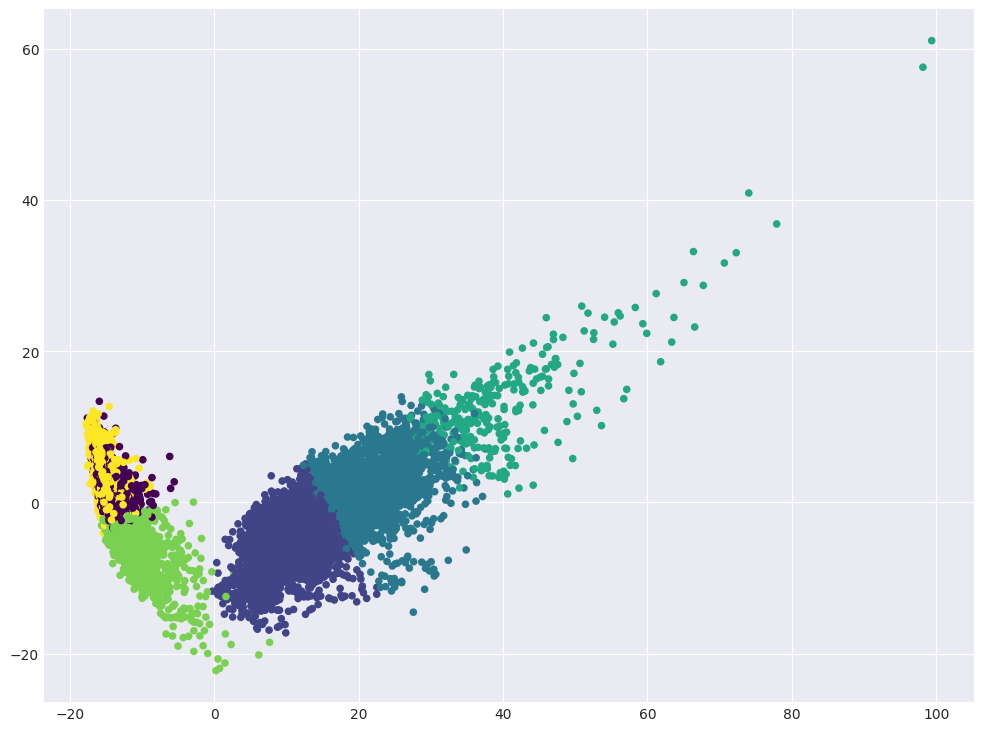

In [43]:
# Ваш код здесь
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, s=20, cmap='viridis');

Посмотрите на соответствие между метками кластеров и исходными метками классов и на то, какие виды активностей алгоритм `KMeans` путает.

In [44]:
tab = pd.crosstab(y, cluster_labels, margins=True)
tab.index = ['ходьба', 'подъем вверх по лестнице',
             'спуск по лестнице', 'сидение', 'стояние', 'лежание', 'все']
tab.columns = ['cluster' + str(i + 1) for i in range(6)] + ['все']
tab

,cluster1,cluster2,cluster3,cluster4,cluster5,cluster6,все
ходьба,0,903,741,78,0,0,1722
подъем вверх по лестнице,0,1241,296,5,2,0,1544
спуск по лестнице,0,320,890,196,0,0,1406
сидение,1235,1,0,0,450,91,1777
стояние,1344,0,0,0,562,0,1906
лежание,52,5,0,0,329,1558,1944
все,2631,2470,1927,279,1343,1649,10299


Видим, что каждому классу (т.е. каждой активности) соответствуют несколько кластеров. Давайте посмотрим на максимальную долю объектов в классе, отнесенных к какому-то одному кластеру. Это будет простой метрикой, характеризующей, насколько легко класс отделяется от других при кластеризации.

Пример: если для класса "спуск по лестнице", в котором 1406 объектов,  распределение кластеров такое:
 - кластер 1 – 900
 - кластер 3 – 500
 - кластер 6 – 6,

то такая доля будет 900 / 1406 $\approx$ 0.64.


**Вопрос 4:** (1 балл)

Какой вид активности отделился от остальных лучше всего в терминах простой  метрики, описанной выше?<br>

**Ответ:**
- ходьба
- **стояние** - правильный ответ
- спуск по лестнице
- перечисленные варианты не подходят

Видно, что kMeans не очень хорошо отличает только активности друг от друга. Используйте метод локтя, чтобы выбрать оптимальное количество кластеров. Параметры алгоритма и данные используем те же, что раньше, меняем только `n_clusters`.

100%|██████████| 6/6 [00:03<00:00,  1.98it/s]


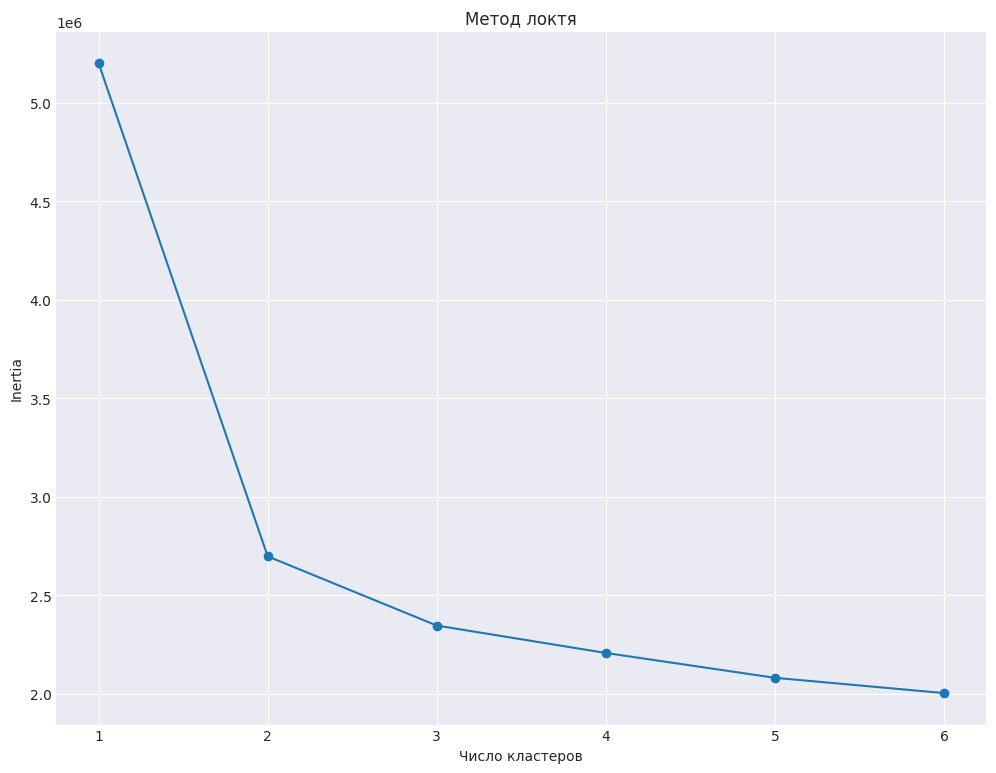

In [45]:
# Ваш код здесь
from tqdm import tqdm
inertia = []
for k in tqdm(range(1, n_classes + 1)):
    kmeans = KMeans(n_clusters=k, n_init=100, random_state=RANDOM_STATE)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, n_classes + 1), inertia, marker='o')
plt.xlabel('Число кластеров')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.grid(True)
plt.show()

**Вопрос 5:** (1 балл)

Какое количество кластеров оптимально выбрать, согласно методу локтя?<br>

**Ответ:**
- 1
- **2** - правильный ответ
- 3
- 4

------------------------

Попробуем еще один метод кластеризации, который описывался в статье – агломеративную кластеризацию.

In [46]:
ag = AgglomerativeClustering(n_clusters=n_classes,
                             linkage='ward').fit(X_pca)

Посчитайте Adjusted Rand Index (`sklearn.metrics`) для получившегося разбиения на кластеры и для `KMeans` с параметрами из задания к 4 вопросу.

In [47]:
# Ваш код здесь
ari_kmeans = metrics.adjusted_rand_score(y, cluster_labels)
ari_ag = metrics.adjusted_rand_score(y, ag.labels_)

print(f"ARI для KMeans: {ari_kmeans:.4f}")
print(f"ARI для Agglomerative Clustering: {ari_ag:.4f}")

ARI для KMeans: 0.4198
ARI для Agglomerative Clustering: 0.4936


**Вопрос 6:** (1 балл)

Отметьте все верные утверждения.<br>

**Варианты:**
- **Согласно ARI, KMeans справился с кластеризацией хуже, чем Agglomerative Clustering**
- **Для ARI не имеет значения какие именно метки присвоены кластерам, имеет значение только разбиение объектов на кластеры**
- **В случае случайного разбиения на кластеры ARI будет близок к нулю**

Все утверждения верны

-------------------------------

Можно заметить, что задача не очень хорошо решается именно как задача кластеризации, если выделять несколько кластеров (> 2). Давайте теперь решим задачу классификации, вспомнив, что данные у нас размечены.  

Для классификации используйте метод опорных векторов – класс `sklearn.svm.LinearSVC`. Мы в курсе отдельно не рассматривали этот алгоритм, но он очень известен, почитать про него можно, например, в материалах Евгения Соколова –  [тут](https://github.com/esokolov/ml-course-msu/blob/master/ML16/lecture-notes/Sem11_linear.pdf).

Настройте для `LinearSVC` гиперпараметр `C` с помощью `GridSearchCV`.

- Обучите новый `StandardScaler` на обучающей выборке (со всеми исходными признаками), прмиените масштабирование к тестовой выборке
- В `GridSearchCV` укажите  cv=3.

In [48]:
# Ваш код здесь
scaler_svc = StandardScaler()
X_train_scaled = scaler_svc.fit_transform(X_train)
X_test_scaled = scaler_svc.transform(X_test)

In [51]:
svc = LinearSVC(random_state=RANDOM_STATE, max_iter=5000)
svc_params = {'C': [0.001, 0.01, 0.1, 1, 10]}

In [52]:
# Ваш код здесь
best_svc = GridSearchCV(svc, svc_params, cv=3)
best_svc.fit(X_train_scaled, y_train)

,estimator,LinearSVC(max...ndom_state=17)
,param_grid,"{'C': [0.001, 0.01, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [53]:
# Ваш код здесь
print(f"Лучший параметр C: {best_svc.best_params_['C']}")
print(f"Лучшее качество на кросс-валидации: {best_svc.best_score_:.4f}")

Лучший параметр C: 0.1
Лучшее качество на кросс-валидации: 0.9381


**Вопрос 7** (0.5 баллов)

Какое значение гиперпараметра `C` было выбрано лучшим по итогам кросс-валидации?<br>

**Ответ:**
- 0.001
- 0.01
- **0.1** - лучшее значение
- 1
- 10

In [54]:
y_predicted = best_svc.predict(X_test_scaled)

In [55]:
tab = pd.crosstab(y_test, y_predicted, margins=True)
tab.index = ['ходьба', 'подъем вверх по лестнице', 'спуск по лестнице',
             'сидение', 'стояние', 'лежание', 'все']
tab.columns = tab.index
tab

,ходьба,подъем вверх по лестнице,спуск по лестнице,сидение,стояние,лежание,все
ходьба,494,2,0,0,0,0,496
подъем вверх по лестнице,12,459,0,0,0,0,471
спуск по лестнице,2,4,413,1,0,0,420
сидение,0,4,0,427,60,0,491
стояние,0,0,0,15,517,0,532
лежание,0,0,0,0,11,526,537
все,508,469,413,443,588,526,2947


**Вопрос 8:** (0.5 балл)

Какой вид активности SVM определяет хуже всего в терминах точности? Полноты? <br>

**Ответ:**
- по точности – подъем вверх по лестнице, по полноте – лежание
- по точности – лежание, по полноте – сидение
- по точности – ходьба, по полноте – ходьба
- **по точности – сидение, по полноте – стояние**

In [58]:
# Вычислить precision и recall для каждой активности
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_predicted)
activities = ['ходьба', 'подъем вверх по лестнице', 'спуск по лестнице', 'сидение', 'стояние', 'лежание']

print("Precision and Recall for each activity:")
for i, activity in enumerate(activities):
    print(f"{activity}: Precision={precision[i]:.4f}, Recall={recall[i]:.4f}")

worst_precision_idx = np.argmin(precision)
worst_recall_idx = np.argmin(recall)

print(f"\nХуже всего по точности: {activities[worst_precision_idx]} ({precision[worst_precision_idx]:.4f})")
print(f"Хуже всего по полноте: {activities[worst_recall_idx]} ({recall[worst_recall_idx]:.4f})")


Precision and Recall for each activity:
ходьба: Precision=0.9724, Recall=0.9960
подъем вверх по лестнице: Precision=0.9787, Recall=0.9745
спуск по лестнице: Precision=1.0000, Recall=0.9833
сидение: Precision=0.9639, Recall=0.8697
стояние: Precision=0.8793, Recall=0.9718
лежание: Precision=1.0000, Recall=0.9795

Хуже всего по точности: стояние (0.8793)
Хуже всего по полноте: сидение (0.8697)


Наконец, проделайте то же самое, что в 7 вопросе, только добавив PCA.

- Используйте выборки `X_train_scaled` и `X_test_scaled`
- Обучите тот же PCA, что раньше, на отмасшабированной обучающей выборке, примените преобразование к тестовой
- Настройте гиперпараметр `C` на кросс-валидации по обучающей выборке с PCA-преобразованием. Вы заметите, насколько это проходит быстрее, чем раньше.

**Вопрос 9:** (1 балл)

Какова разность между лучшим качеством (долей верных ответов) на кросс-валидации в случае всех 561 исходных признаков и во втором случае, когда применялся метод главных компонент? Округлите до целых процентов.<br>

**Варианты:**
- Качество одинаковое
- 2%
- **4%** - правильный ответ
- 10%
- 20%

In [59]:
# Ваш код здесь
pca_svc = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_train_pca = pca_svc.fit_transform(X_train_scaled)
X_test_pca = pca_svc.transform(X_test_scaled)

svc_pca = LinearSVC(random_state=RANDOM_STATE, max_iter=5000)
best_svc_pca = GridSearchCV(svc_pca, svc_params, cv=3)
best_svc_pca.fit(X_train_pca, y_train)

print(f"Лучший параметр C с PCA: {best_svc_pca.best_params_['C']}")
print(f"Лучшее качество на кросс-валидации с PCA: {best_svc_pca.best_score_:.4f}")
print(f"Разность в качестве: {abs(best_svc.best_score_ - best_svc_pca.best_score_):.4f}")
print(f"Разность в процентах: {round(abs(best_svc.best_score_ - best_svc_pca.best_score_) * 100)}%")

Лучший параметр C с PCA: 0.1
Лучшее качество на кросс-валидации с PCA: 0.8984
Разность в качестве: 0.0397
Разность в процентах: 4%


**Вопрос 10:** (1 балл)

Выберите все верные утверждения:

**Варианты:**
- Метод главных компонент в данном случае позволил уменьшить время обучения модели, при этом качество (доля верных ответов на кросс-валидации) очень пострадало, более чем на 10%
- **PCA можно использовать для визуализации данных, однако для этой задачи есть и лучше подходящие методы, например, tSNE. Зато PCA имеет меньшую вычислительную сложность** - верно
- **PCA строит линейные комбинации исходных признаков, и в некоторых задачах они могут плохо интерпретироваться человеком** - верно

**Задание 2.** (1 балл)

Попробуйте использовать DBSCAN в качестве алгоритма кластеризации и метод понижения размерности tSNE.

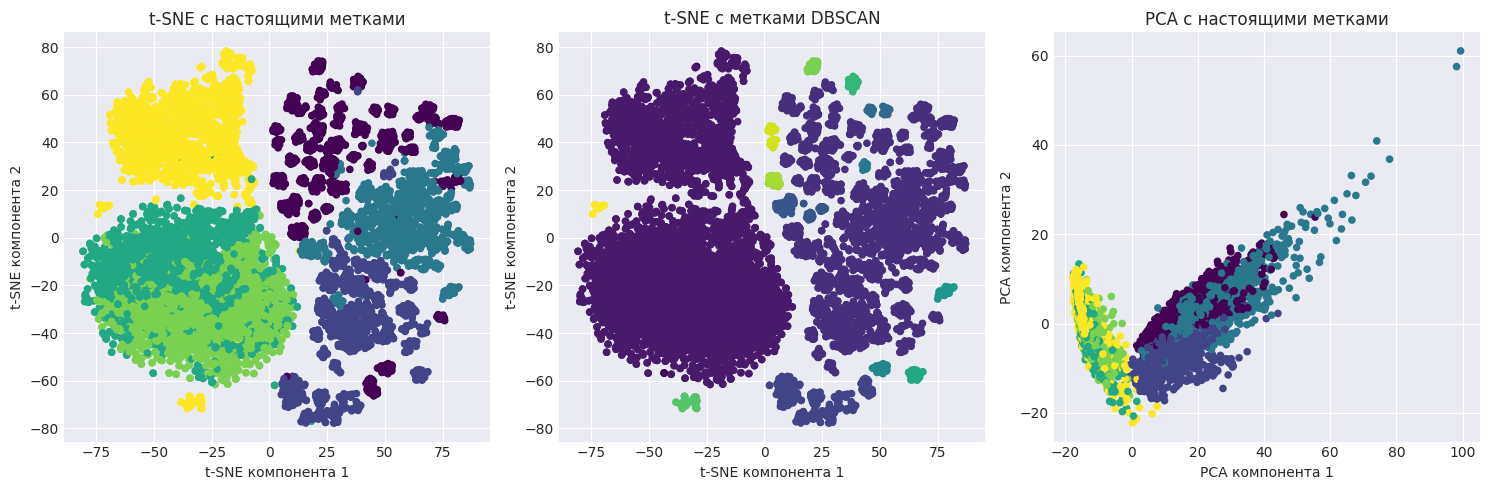

Количество кластеров DBSCAN: 15
Количество точек-выбросов: 5
ARI для DBSCAN: 0.3148


In [60]:
# Ваш код здесь
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE

# Применяем t-SNE для понижения размерности
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Применяем DBSCAN для кластеризации
dbscan = DBSCAN(eps=5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_tsne)

# Визуализация результатов
plt.figure(figsize=(15, 5))

# График с настоящими метками
plt.subplot(1, 3, 1)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, s=20, cmap='viridis')
plt.title('t-SNE с настоящими метками')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')

# График с метками DBSCAN
plt.subplot(1, 3, 2)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=dbscan_labels, s=20, cmap='viridis')
plt.title('t-SNE с метками DBSCAN')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')

# График с первыми двумя компонентами PCA для сравнения
plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, cmap='viridis')
plt.title('PCA с настоящими метками')
plt.xlabel('PCA компонента 1')
plt.ylabel('PCA компонента 2')

plt.tight_layout()
plt.show()

print(f"Количество кластеров DBSCAN: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"Количество точек-выбросов: {list(dbscan_labels).count(-1)}")
print(f"ARI для DBSCAN: {metrics.adjusted_rand_score(y, dbscan_labels):.4f}")